<a href="https://colab.research.google.com/github/nat-lopez/PROYECTO/blob/main/PROYECTO_FINAL_Nat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clasificación de pacientes para la predicción de especialidad médica

###**Objetivo**
Desarrollar modelos de clasificación capaces de predecir la especialidad médica de un paciente utilizando información demográfica y administrativa.

###**Justificación**
La clasificación automática de pacientes puede ayudar a optimizar procesos hospitalarios y mejorar la asignación de recursos médicos. Mediante técnicas de Machine Learning es posible identificar patrones en los datos de los pacientes y predecir la especialidad médica a la que podrían ser canalizados.


###**Variable objetivo**

La variable objetivo seleccionada es: especialidad, la cual representa la especialidad médica asociada al paciente.

###**Modelos a comparar**


*  Decision Tree
*  Random Forest





In [1]:
# IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Configuración visual
plt.style.use('default')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# CARGA DEL DATASET

df = pd.read_csv("/content/sample_data/MOCK_DATA (2) (1).csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(1000, 17)


,id,fecha,diagnostico,no_exp,ref_inetr,especialid,nombre,lugar_d_n,fecha_naci,sexo,edad,nacionalid,otra_nacio,estado_civ,escolaridad,ocupación,calle_y__
0,1,11/10/2025,T63,12,C//E,ESTOM,Brendin Caile,Magnitogorsk,21/02/2026,M,23,Russia,China,SOL,SECUNDARIA,EMPLEADO,Room 1150
1,2,21/01/2025,S52001P,41,C/EI,CARDI,Dalston Ipgrave,Shanban,14/07/2025,F,38,China,Indonesia,SEP,SECUNARIA,PRMARIA,Apt 1207
2,3,18/07/2025,S83522A,49,URG,NEUMP,Fiorenze Herreran,Hà Đông,28/08/2025,M,14,Vietnam,Nicaragua,CAS,MENOR,HOGAR,10th Floor
3,4,23/07/2025,H0501,45,C//E,NEUMO,Robena Divis,Gurra e Vogël,08/04/2025,M,90,Albania,Indonesia,VIU,PRPIMARIA,EMPLEADO,PO Box 12175
4,5,27/08/2025,A1882,78,C//E,ORKL,Domini Yitzhakof,Tianchi,10/04/2025,F,23,China,Ghana,CAS,ANALFEBAT,ESTUDIANTE,3rd Floor


###**Análisis de datos**
Se realiza una exploración inicial del conjunto de datos para identificar la cantidad de registros, variables disponibles, tipos de datos y posibles valores faltantes.

In [6]:
# Info general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1000 non-null   int64 
 1   fecha        1000 non-null   object
 2   diagnostico  1000 non-null   object
 3   no_exp       1000 non-null   int64 
 4   ref_inetr    1000 non-null   object
 5   especialid   1000 non-null   object
 6   nombre       1000 non-null   object
 7   lugar_d_n    1000 non-null   object
 8   fecha_naci   1000 non-null   object
 9   sexo         1000 non-null   object
 10  edad         1000 non-null   int64 
 11  nacionalid   1000 non-null   object
 12  otra_nacio   1000 non-null   object
 13  estado_civ   1000 non-null   object
 14  escolaridad  1000 non-null   object
 15  ocupación    1000 non-null   object
 16  calle_y__    1000 non-null   object
dtypes: int64(3), object(14)
memory usage: 132.9+ KB


In [7]:
# Estadística descriptiva

df.describe(include='all')

,id,fecha,diagnostico,no_exp,ref_inetr,especialid,nombre,lugar_d_n,fecha_naci,sexo,edad,nacionalid,otra_nacio,estado_civ,escolaridad,ocupación,calle_y__
count,1000.000000,1000,1000,1000.000000,1000,1000,1000,1000,1000,1000,1000.000000,1000,1000,1000,1000,1000,1000
unique,NaN,343,994,NaN,5,6,1000,976,341,2,NaN,113,122,8,18,21,686
top,NaN,07/02/2025,S3115,NaN,C/E,CARDI,Shelley Tapner,Oslo,28/08/2025,M,NaN,China,China,UNI,PROESIONAL,CHOFER,17th Floor
freq,NaN,9,2,NaN,214,182,1,4,8,543,NaN,177,194,142,66,93,17
mean,500.500000,NaN,NaN,49.766000,NaN,NaN,NaN,NaN,NaN,NaN,51.399000,NaN,NaN,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,28.383073,NaN,NaN,NaN,NaN,NaN,NaN,29.216423,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,250.750000,NaN,NaN,25.750000,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,500.500000,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,53.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,750.250000,NaN,NaN,75.000000,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Valores faltantes

df.isnull().sum()

,0
id,0
fecha,0
diagnostico,0
no_exp,0
ref_inetr,0
especialid,0
nombre,0
lugar_d_n,0
fecha_naci,0
sexo,0


###**Distribución de Edades**

La edad es una de las variables más importantes del dataset, por lo que se analiza su distribución.

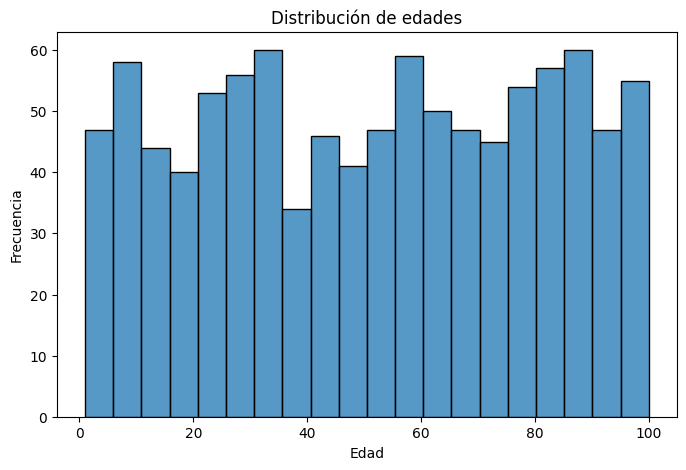

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["edad"], bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

###**Distribución por Sexo**

Se analiza la proporción de pacientes masculinos y femeninos presentes en el conjunto de datos.

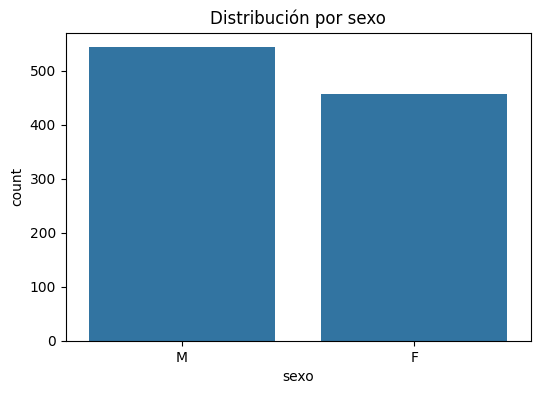

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="sexo")

plt.title("Distribución por sexo")

plt.show()

###**Distribución de Especialidades Médicas**

La variable `especialid` será utilizada como variable objetivo del proyecto.

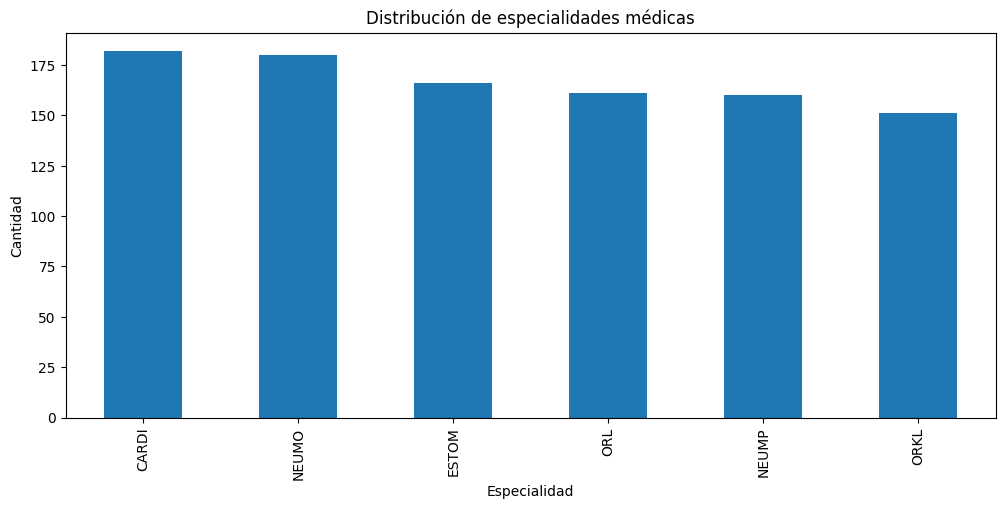

In [11]:
plt.figure(figsize=(12,5))

df["especialid"].value_counts().plot(kind="bar")

plt.title("Distribución de especialidades médicas")
plt.xlabel("Especialidad")
plt.ylabel("Cantidad")

plt.show()

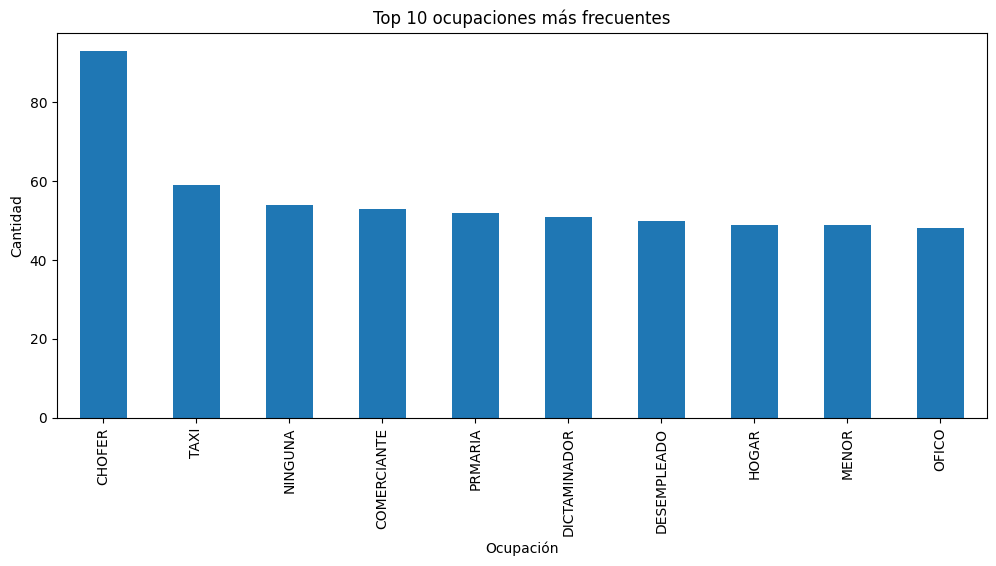

In [13]:
# Top ocupaciones

plt.figure(figsize=(12,5))

df["ocupación"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 ocupaciones más frecuentes")
plt.xlabel("Ocupación")
plt.ylabel("Cantidad")

plt.show()

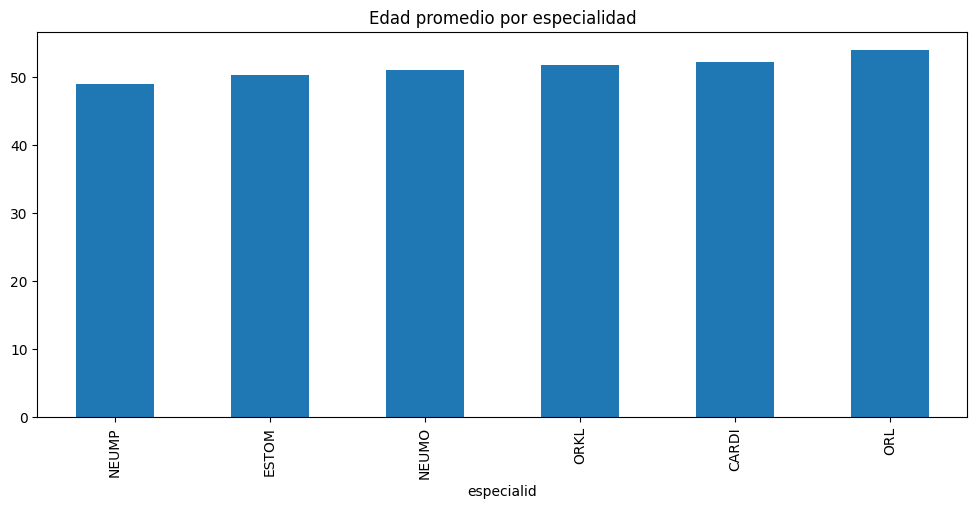

In [14]:
# Edad promedio por especialidad

edad_especialidad = (
    df.groupby("especialid")["edad"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,5))

edad_especialidad.plot(kind="bar")

plt.title("Edad promedio por especialidad")

plt.show()

###**Preprocesamiento**

Las variables categóricas son convertidas a formato numérico mediante Label Encoding para permitir el entrenamiento de los modelos.

In [28]:
df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:

    if df_ml[col].dtype == "object":

        df_ml[col] = le.fit_transform(
            df_ml[col].astype(str)
        )

df_ml.head()

,id,fecha,diagnostico,no_exp,ref_inetr,especialid,nombre,lugar_d_n,fecha_naci,sexo,edad,nacionalid,otra_nacio,estado_civ,escolaridad,ocupación,calle_y__
0,1,122,859,12,0,1,155,481,224,1,23,86,22,3,16,9,427
1,2,226,460,41,3,0,271,733,150,0,38,18,50,2,15,19,45
2,3,196,683,49,4,3,383,319,311,1,14,109,81,0,4,13,0
3,4,255,83,45,0,2,803,291,81,1,90,1,50,6,14,9,232
4,5,301,1,78,0,4,306,816,103,0,23,18,41,0,2,10,13


In [31]:
# Definición de variables predictoras y target

X = df_ml.drop([
    "especialid",
    "id",
    "nombre",
    "no_exp",
    "calle_y__"
], axis=1)

In [32]:
# División entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (800, 12)
Prueba: (200, 12)


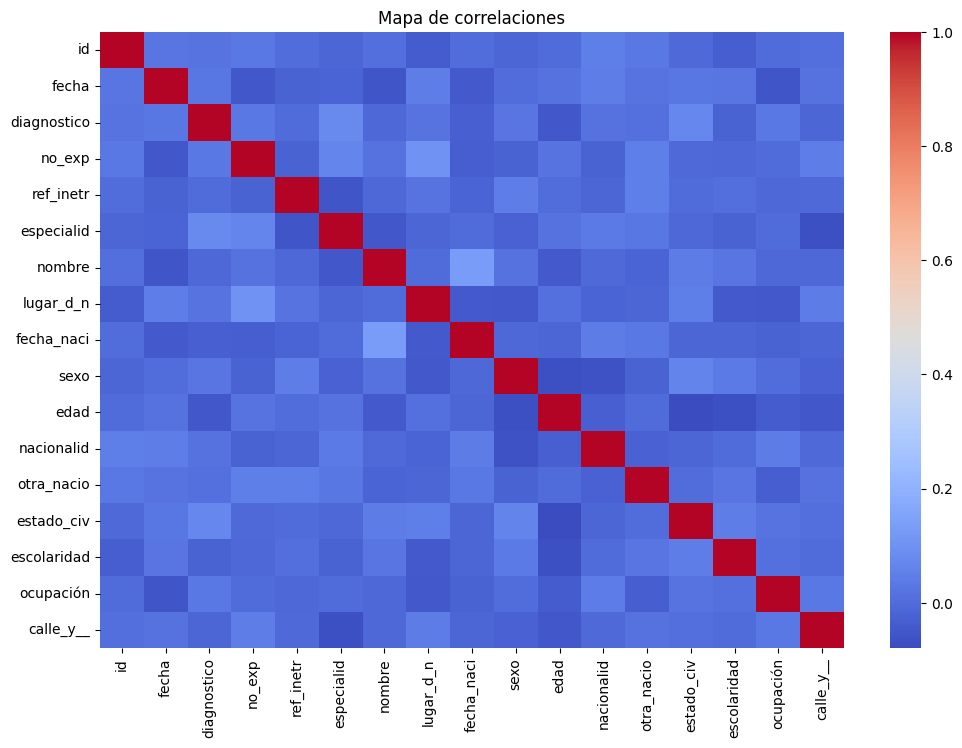

In [33]:
# Heatmap de correlaciones

plt.figure(figsize=(12,8))

sns.heatmap(
    df_ml.corr(),
    cmap="coolwarm"
)

plt.title("Mapa de correlaciones")

plt.show()

###**Modelo 1: Decision Tree**

Se entrena un Árbol de Decisión para predecir la especialidad médica del paciente.

In [34]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train,y_train)

pred_tree = tree.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test,pred_tree))

print("\nReporte de clasificación:")
print(classification_report(y_test,pred_tree))

Accuracy:
0.16

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.15      0.12      0.13        41
           1       0.15      0.25      0.18        24
           2       0.12      0.14      0.13        29
           3       0.19      0.12      0.14        42
           4       0.17      0.23      0.19        31
           5       0.21      0.15      0.18        33

    accuracy                           0.16       200
   macro avg       0.16      0.17      0.16       200
weighted avg       0.16      0.16      0.16       200



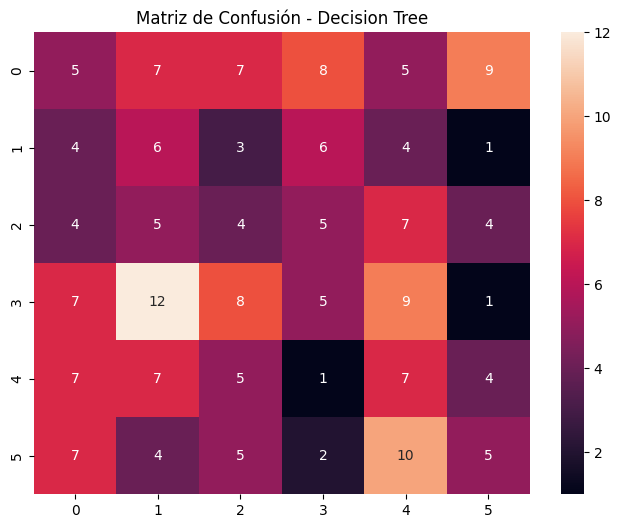

In [35]:
cm = confusion_matrix(
    y_test,
    pred_tree
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Decision Tree")

plt.show()

 La matriz de confusión muestra que el modelo logró clasificar correctamente algunos pacientes, aunque también presentó errores al diferenciar ciertas especialidades médicas. La presencia de varios valores fuera de la diagonal principal indica que existen similitudes entre algunas categorías, lo que dificulta la clasificación precisa utilizando únicamente las variables disponibles en el dataset.

###**Modelo 2: Random Forest**

Se entrena un Random Forest para comparar su desempeño con el Árbol de Decisión.

In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test,pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test,pred_rf))

Accuracy:
0.2

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.24      0.27      0.25        41
           1       0.13      0.21      0.16        24
           2       0.19      0.28      0.22        29
           3       0.30      0.19      0.23        42
           4       0.20      0.13      0.16        31
           5       0.15      0.12      0.14        33

    accuracy                           0.20       200
   macro avg       0.20      0.20      0.19       200
weighted avg       0.21      0.20      0.20       200



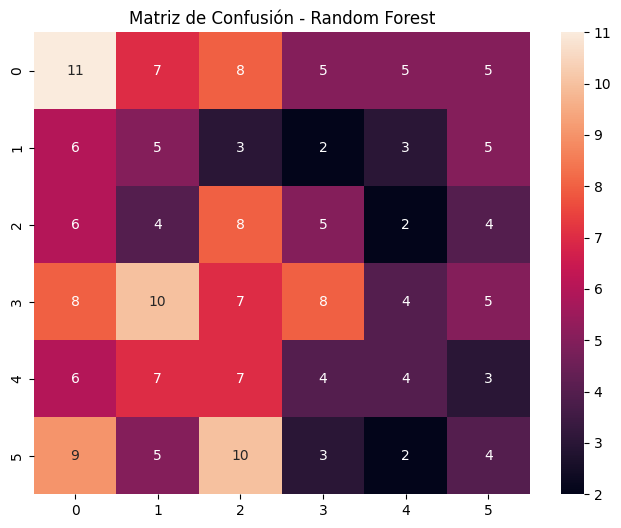

In [37]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Random Forest")

plt.show()

Se observa que Random Forest obtuvo más predicciones correctas, representadas por los valores de la diagonal principal. No obstante, aún existen errores de clasificación entre algunas especialidades médicas, lo que indica que el problema presenta cierta complejidad y que las variables disponibles no son suficientes para distinguir perfectamente todas las clases.

In [38]:
# Importancia de variables

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

importance.head(10)

,Variable,Importancia
1,diagnostico,0.108827
3,lugar_d_n,0.107379
0,fecha,0.104526
4,fecha_naci,0.103633
6,edad,0.102433
8,otra_nacio,0.089897
7,nacionalid,0.085423
11,ocupación,0.081814
10,escolaridad,0.081235
9,estado_civ,0.062564


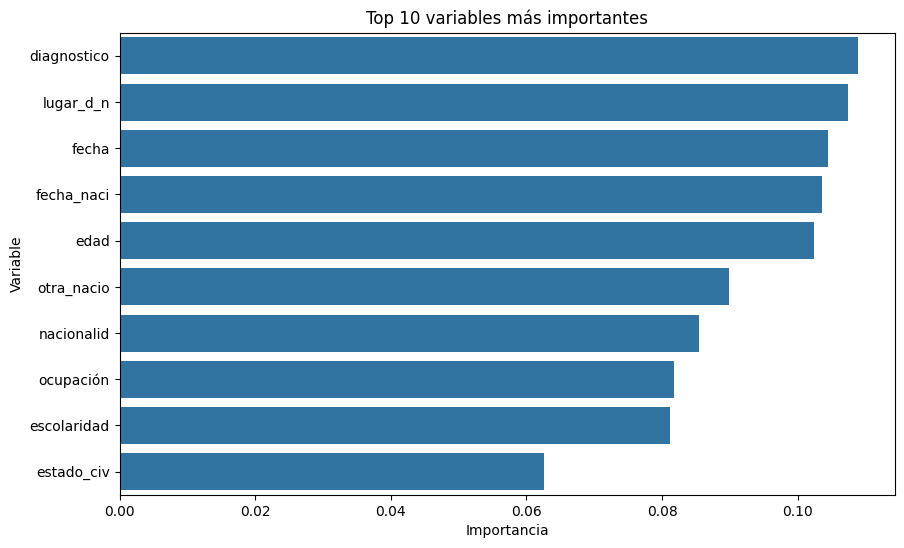

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes")

plt.show()

,Modelo,Accuracy
0,Decision Tree,0.16
1,Random Forest,0.20


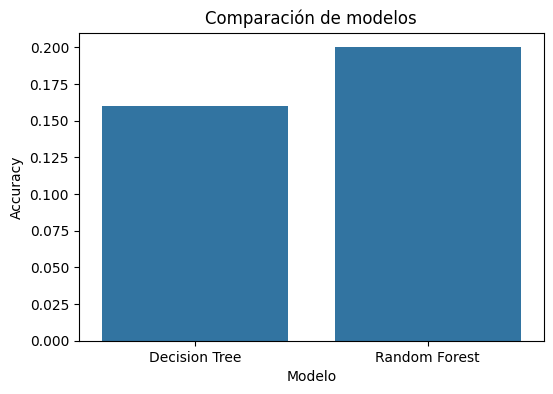

In [40]:
# Comparación de modelos

resultados = pd.DataFrame({
    "Modelo":[
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_tree),
        accuracy_score(y_test,pred_rf)
    ]
})

display(resultados)

plt.figure(figsize=(6,4))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="Accuracy"
)

plt.title("Comparación de modelos")

plt.show()

## **Conclusiones**

En este proyecto se desarrollaron modelos de aprendizaje automático para predecir la especialidad médica de un paciente utilizando información demográfica y administrativa contenida en el dataset analizado.


Se entrenaron y compararon dos modelos de clasificación: Decision Tree y Random Forest. Los resultados obtenidos mostraron que el modelo `Random Forest` alcanzó un Accuracy de 20%, mientras que el modelo `Decision Tree` obtuvo un Accuracy de 16%, por lo que `Random Forest` presentó un mejor desempeño general.


El análisis de importancia de variables indicó que características como lugar de nacimiento, diagnóstico, edad y nacionalidad aportaron información relevante para la clasificación de pacientes. Sin embargo, los resultados sugieren que las variables disponibles no contienen suficiente información para identificar con alta precisión la especialidad médica correspondiente a cada paciente.


***Nathalie López Pérez***